# Guided Numeric Exploration — Dog Adoption Success
_Exploratory walkthrough of returns, fit mismatches, and what associates with a match that lasts_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [sergionefedov/dog-adoption-success-does-the-match-last](https://www.kaggle.com/datasets/sergionefedov/dog-adoption-success-does-the-match-last)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.
Indented lines signify code is part of a larger function or loop. Functions are used to keep the exploratory process simple and reusable.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Distribution](#Univariate)** <br>
	- 3.1 Return outcome and reasons
	- 3.2 Days to return (returns only)
**4. [Fit Mismatches](#Mismatch)** <br>
**5. [Behavior Scores and Household Fit](#Behavior)** <br>
**6. [Process: Counseling, Visits, First-Time Owners](#Process)** <br>
**7. [Dog Size Deep Dive](#Size)** <br>
	- 7.1 Return rate by size
	- 7.2 Return reason by size
**8. [Crosstabs: Size × Home, Kids × Aggression](#Crosstabs)** <br>
**9. [Multivariate Association](#Association)** <br>
**10. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
This notebook is a guided observational walkthrough of a dog-adoption outcomes table: **42,000 adoptions** with dog traits (age, size, breed group, behavior scores), household context (home type, kids, pets, hours alone), process features (visits, counseling), engineered mismatch scores, and a binary `returned` label (~15%).

My goal is to understand **what associates with returns** — especially energy/size mismatches, aggression and anxiety scores, and whether counseling or more visits track lower return rates — while respecting a structural missingness pattern: `days_to_return` is NaN when the dog is kept, and `return_reason` is `"kept"` for non-returns. I will **not** impute days-to-return for kept dogs; timing analysis stays on the returned subset.

Interpretations after each plot are working notes about associations in this table, not prescriptions for shelters or adopters.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances), not a production model. `kagglehub` resolves the CSV both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
CSV_BASENAME = "dog_adoption_master.csv"
KAGGLE_SLUG = "sergionefedov/dog-adoption-success-does-the-match-last"

EXPECTED_COLS = [
    "adoption_id", "age_years", "size", "weight_kg", "breed_group", "intake_type",
    "days_in_shelter", "previously_returned", "medical_needs", "neutered",
    "aggression_score", "anxiety_separation", "reactivity_to_dogs", "energy_level",
    "training_level", "house_trained", "first_time_owner", "household_has_kids",
    "household_has_pets", "home_type", "has_yard", "hours_alone_per_day",
    "adopter_activity_level", "visits_before_adoption", "met_resident_pets",
    "adoption_counseling", "expectation_score", "energy_mismatch",
    "size_home_mismatch", "return_reason", "days_to_return", "returned",
]


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(CSV_BASENAME):
            assert p.is_file()
            return p
        for p in kaggle_root.rglob("*.csv"):
            if "dog_adoption" in p.name.lower() and "dictionary" not in p.name.lower():
                assert p.is_file()
                return p
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / CSV_BASENAME
    assert p.exists(), f"expected {CSV_BASENAME} under {root}"
    return p


csv_path = resolve_csv_path()
print("CSV:", csv_path)

df = pd.read_csv(csv_path, low_memory=False)
missing_cols = set(EXPECTED_COLS) - set(df.columns)
assert not missing_cols, f"missing columns: {sorted(missing_cols)}"
assert len(df) == 42000, f"expected 42000 rows, got {len(df)}"
assert df["returned"].isin([0, 1]).all()

# Structural missingness checks — fail loud if the contract breaks
kept = df["returned"] == 0
returned = df["returned"] == 1
assert df.loc[kept, "days_to_return"].isna().all(), "kept dogs should have NaN days_to_return"
assert df.loc[returned, "days_to_return"].notna().all(), "returned dogs should have days_to_return"
assert (df.loc[kept, "return_reason"] == "kept").all(), "non-returns should be reason=kept"
assert (df.loc[returned, "return_reason"] != "kept").all(), "returns should not be reason=kept"

unique_count = []
for x in df.columns:
    unique_count.append([x, df[x].nunique(dropna=False), int(df[x].isnull().sum())])

print("Missing Values: {}".format(df.isnull().sum().sum()))
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("Return rate: {:.1%}".format(df["returned"].mean()))
print("days_to_return null share: {:.1%} (expected ≈ non-return share)".format(
    df["days_to_return"].isna().mean()
))
print("return_reason == kept share: {:.1%}".format((df["return_reason"] == "kept").mean()))


Missing Values: 35703
Dataframe Dimension: 42000 Rows, 32 Columns
Return rate: 15.0%
days_to_return null share: 85.0% (expected ≈ non-return share)
return_reason == kept share: 85.0%


**Code Explanation and Reasoning:** <br>
After resolving the CSV, I assert schema, row count, and — critically — the missingness contract for `days_to_return` and `return_reason`. Silent imputation of days for kept dogs would invent a fake clock. The printed null share should nearly equal the non-return rate; if it does not, the table definition has drifted.


In [3]:
df.sample(3, random_state=7)


,adoption_id,age_years,size,weight_kg,breed_group,intake_type,days_in_shelter,previously_returned,medical_needs,neutered,aggression_score,anxiety_separation,reactivity_to_dogs,energy_level,training_level,house_trained,first_time_owner,household_has_kids,household_has_pets,home_type,has_yard,hours_alone_per_day,adopter_activity_level,visits_before_adoption,met_resident_pets,adoption_counseling,expectation_score,energy_mismatch,size_home_mismatch,return_reason,days_to_return,returned
12504,ADP012504,7.2,xlarge,46.8,hound,owner_surrender,60,0,none,1,5.6,1.1,5.7,5.7,3.2,0,0,0,0,house_owned,1,7.0,7.8,1,0,1,2.5,2.1,0,kept,NaN,0
18431,ADP018431,5.0,small,8.2,working,owner_surrender,3,0,minor,1,5.8,5.7,2.2,6.6,4.5,1,1,0,1,house_owned,0,4.7,3.6,3,0,1,7.9,3.0,0,aggression,3.0,1
184,ADP000184,1.4,small,10.6,working,stray,24,0,none,1,0.9,2.6,0.5,5.7,0.8,1,1,0,0,house_owned,1,5.4,4.8,2,0,1,4.4,0.9,0,kept,NaN,0


In [4]:
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Missing"]).sort_values("Missing", ascending=False))


Dataframe Dimension: 42000 Rows, 32 Columns


,Column,Unique,Missing
30,days_to_return,876,35703
0,adoption_id,42000,0
1,age_years,159,0
29,return_reason,10,0
28,size_home_mismatch,2,0
27,energy_mismatch,101,0
26,expectation_score,101,0
25,adoption_counseling,2,0
24,met_resident_pets,2,0
23,visits_before_adoption,4,0


**Interpretation** <br>
~15% of adoptions return. The only heavy missingness is `days_to_return`, and it is *structural* (kept = no return clock), not a random hole. Behavior scores and mismatch features look complete — good for bivariate rate plots. `return_reason="kept"` is a non-event label; when I study reasons, I will filter to actual returns.


# **3. Univariate Distribution:** <a id="Univariate"></a>
### 3.1 Return outcome and reasons


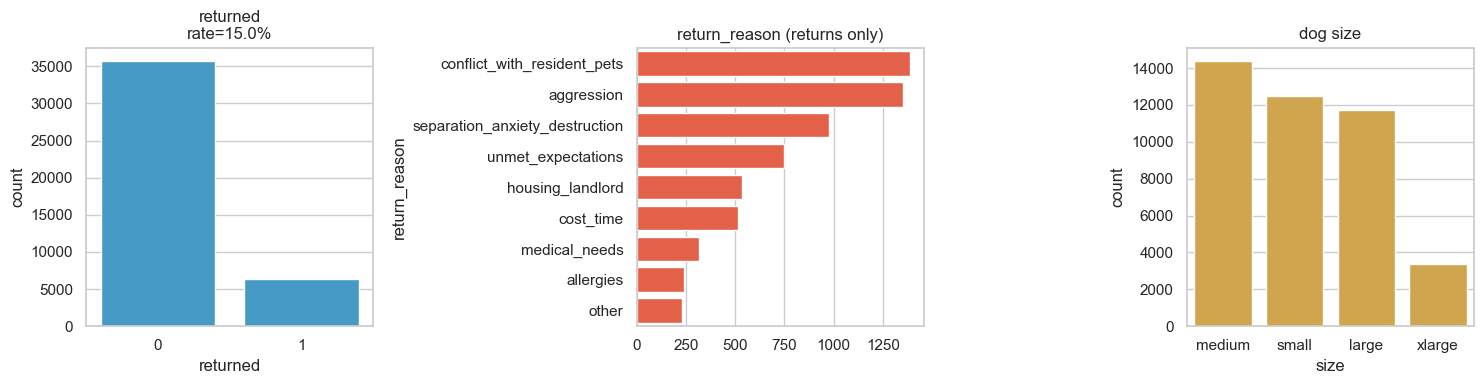

AGENT_SUMMARY return_rate=0.150
AGENT_SUMMARY return_reasons:
 return_reason
conflict_with_resident_pets       1387
aggression                        1352
separation_anxiety_destruction     975
unmet_expectations                 750
housing_landlord                   535
cost_time                          512
medical_needs                      316
allergies                          238
other                              232


In [5]:
f, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x=df["returned"], ax=ax[0], color="#30a2da")
ax[0].set_title("returned\nrate={:.1%}".format(df["returned"].mean()))

reasons = df.loc[df["returned"] == 1, "return_reason"].value_counts()
sns.barplot(x=reasons.values, y=reasons.index, ax=ax[1], color="#fc4f30")
ax[1].set_title("return_reason (returns only)")

sns.countplot(data=df, x="size", order=df["size"].value_counts().index, ax=ax[2], color="#e5ae38")
ax[2].set_title("dog size")
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY return_rate={:.3f}".format(df["returned"].mean()))
print("AGENT_SUMMARY return_reasons:\n", reasons.to_string())


**Code Explanation:** <br>
The middle panel deliberately drops `kept`. Including it would dominate the bar chart and hide why returns happen. Size on the right is context for later size × home crosstabs.


### 3.2 Days to return (returns only)


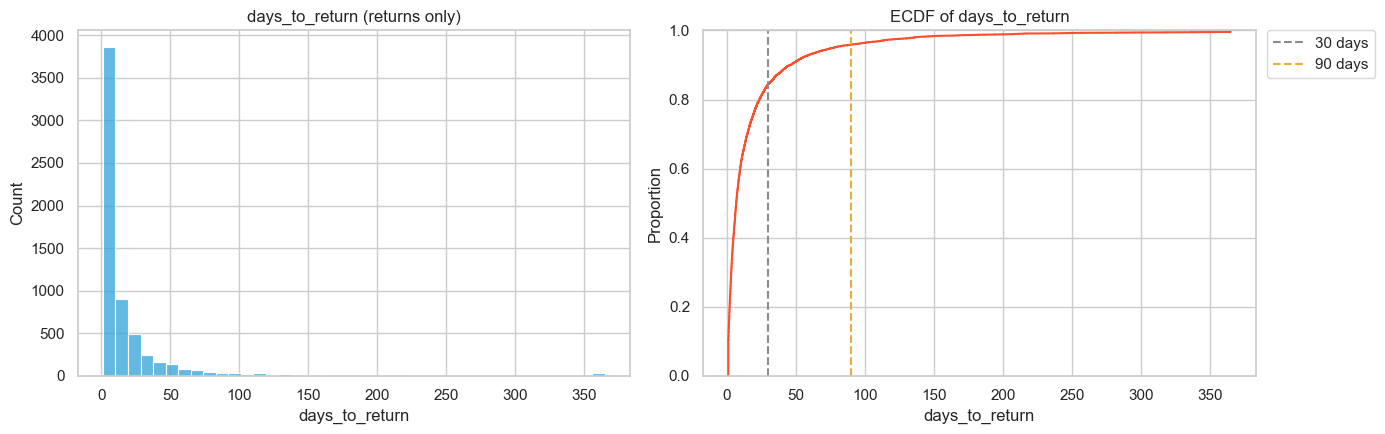

AGENT_SUMMARY days_to_return: mean=19.4 median=6.7 p25=2 p75=18 share_le_30=84.5% share_le_90=95.9%


In [6]:
ret = df[df["returned"] == 1].copy()
assert ret["days_to_return"].notna().all()

f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(ret["days_to_return"], bins=40, ax=ax[0], color="#30a2da")
ax[0].set_title("days_to_return (returns only)")

sns.ecdfplot(ret["days_to_return"], ax=ax[1], color="#fc4f30")
ax[1].set_title("ECDF of days_to_return")
ax[1].axvline(30, color="#8b8b8b", ls="--", label="30 days")
ax[1].axvline(90, color="#e5ae38", ls="--", label="90 days")
ax[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

print("AGENT_SUMMARY days_to_return: mean={:.1f} median={:.1f} p25={:.0f} p75={:.0f} share_le_30={:.1%} share_le_90={:.1%}".format(
    ret["days_to_return"].mean(), ret["days_to_return"].median(),
    ret["days_to_return"].quantile(0.25), ret["days_to_return"].quantile(0.75),
    (ret["days_to_return"] <= 30).mean(), (ret["days_to_return"] <= 90).mean(),
))


**Interpretation:** <br>
Returns pile up early — the left side of the histogram and the steep early ECDF are the story. Many failed matches declare themselves within the first month or quarter. That timing matters for shelter follow-up design more than a mean alone would suggest.


# **4. Fit Mismatches:** <a id="Mismatch"></a>


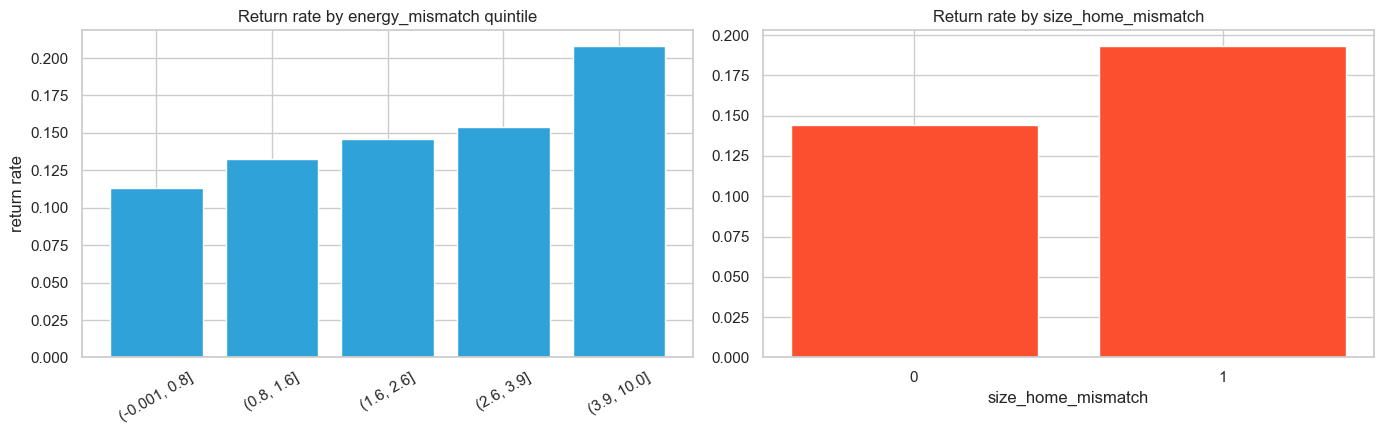

AGENT_SUMMARY energy_mismatch_return:
                     mean  count
energy_mismatch_q              
(-0.001, 0.8]      0.113   9140
(0.8, 1.6]         0.133   7991
(1.6, 2.6]         0.146   8632
(2.6, 3.9]         0.154   8051
(3.9, 10.0]        0.208   8186
AGENT_SUMMARY size_home_mismatch_return:
                      mean  count
size_home_mismatch              
0                   0.144  37228
1                   0.193   4772
AGENT_SUMMARY spearman energy_mismatch~returned=0.087


In [7]:
f, ax = plt.subplots(1, 2, figsize=(14, 4.5))

df["energy_mismatch_q"] = pd.qcut(df["energy_mismatch"], 5, duplicates="drop")
em = df.groupby("energy_mismatch_q", observed=True)["returned"].agg(["mean", "count"])
ax[0].bar(em.index.astype(str), em["mean"], color="#30a2da")
ax[0].set_title("Return rate by energy_mismatch quintile")
ax[0].tick_params(axis="x", rotation=30)
ax[0].set_ylabel("return rate")

sm = df.groupby("size_home_mismatch")["returned"].agg(["mean", "count"])
ax[1].bar(sm.index.astype(str), sm["mean"], color="#fc4f30")
ax[1].set_title("Return rate by size_home_mismatch")
ax[1].set_xlabel("size_home_mismatch")
plt.tight_layout()
plt.show()

print("AGENT_SUMMARY energy_mismatch_return:\n", em.round(3).to_string())
print("AGENT_SUMMARY size_home_mismatch_return:\n", sm.round(3).to_string())
print("AGENT_SUMMARY spearman energy_mismatch~returned={:.3f}".format(
    stats.spearmanr(df["energy_mismatch"], df["returned"]).correlation
))


**How to Interpret:** <br>
Engineered mismatches are the table author's theory of fit made numeric. A rising return rate across energy-mismatch quintiles supports that theory in-sample. `size_home_mismatch` as a binary/integer flag should show a step, not a smooth curve. These are still associations — mismatch features may encode the same information as raw size/home fields.


# **5. Behavior Scores and Household Fit:** <a id="Behavior"></a>


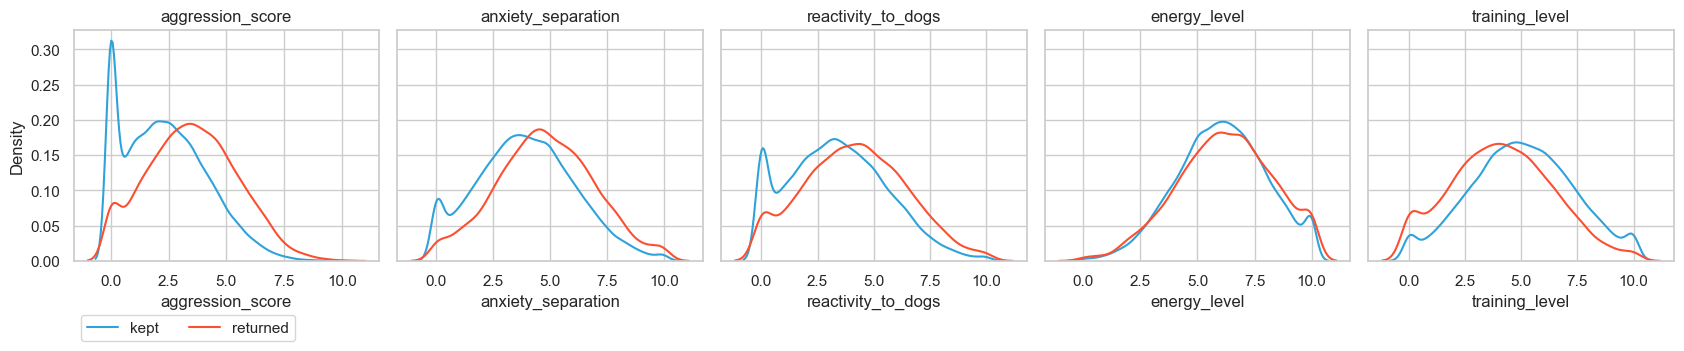

AGENT_SUMMARY behavior_means_by_returned:
          aggression_score  anxiety_separation  reactivity_to_dogs  energy_level  training_level
returned                                                                                        
0                    2.348               3.924               3.381         6.073           5.033
1                    3.516               4.795               4.174         6.202           4.138


In [8]:
behavior_cols = ["aggression_score", "anxiety_separation", "reactivity_to_dogs", "energy_level", "training_level"]

f, axes = plt.subplots(1, len(behavior_cols), figsize=(17, 3.8), sharey=True)
for ax, col in zip(axes, behavior_cols):
    sns.kdeplot(df.loc[df["returned"] == 0, col], ax=ax, label="kept", color="#30a2da")
    sns.kdeplot(df.loc[df["returned"] == 1, col], ax=ax, label="returned", color="#fc4f30")
    ax.set_title(col)
axes[0].legend(loc="upper left", bbox_to_anchor=(0, -0.2), ncol=2)
plt.tight_layout()
plt.show()

print("AGENT_SUMMARY behavior_means_by_returned:")
print(df.groupby("returned")[behavior_cols].mean().round(3).to_string())


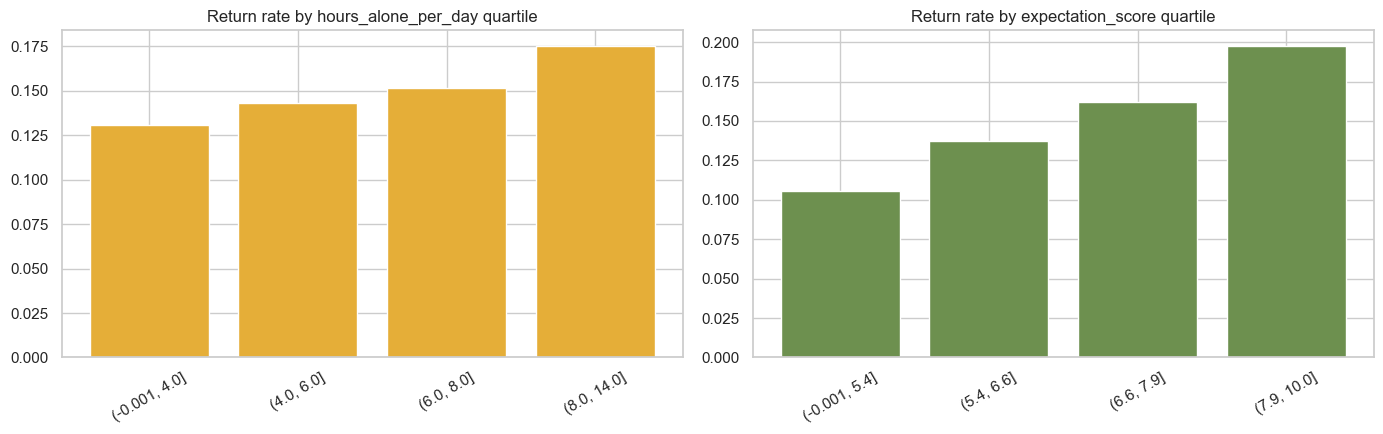

AGENT_SUMMARY hours_alone_return:
                 mean  count
hours_q                    
(-0.001, 4.0]  0.131  10828
(4.0, 6.0]     0.143  10489
(6.0, 8.0]     0.152  10471
(8.0, 14.0]    0.175  10212
AGENT_SUMMARY expectation_return:
                 mean  count
expect_q                   
(-0.001, 5.4]  0.105  11135
(5.4, 6.6]     0.137   9920
(6.6, 7.9]     0.162  10450
(7.9, 10.0]    0.198  10495


In [9]:
# Hours alone and expectation score
f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
df["hours_q"] = pd.qcut(df["hours_alone_per_day"], 4, duplicates="drop")
hq = df.groupby("hours_q", observed=True)["returned"].mean()
ax[0].bar(hq.index.astype(str), hq.values, color="#e5ae38")
ax[0].set_title("Return rate by hours_alone_per_day quartile")
ax[0].tick_params(axis="x", rotation=30)

df["expect_q"] = pd.qcut(df["expectation_score"], 4, duplicates="drop")
eq = df.groupby("expect_q", observed=True)["returned"].mean()
ax[1].bar(eq.index.astype(str), eq.values, color="#6d904f")
ax[1].set_title("Return rate by expectation_score quartile")
ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY hours_alone_return:\n", df.groupby("hours_q", observed=True)["returned"].agg(["mean", "count"]).round(3).to_string())
print("AGENT_SUMMARY expectation_return:\n", df.groupby("expect_q", observed=True)["returned"].agg(["mean", "count"]).round(3).to_string())


**Interpretation:** <br>
Returned dogs sit higher on aggression and separation anxiety in the density overlays — the separation between curves is the signal. Hours alone and expectation score ask whether household logistics and adopter mindset track outcomes. Training level may move the other way (more training, fewer returns), which is a hopeful process lever if the association holds under controls.


# **6. Process: Counseling, Visits, First-Time Owners:** <a id="Process"></a>


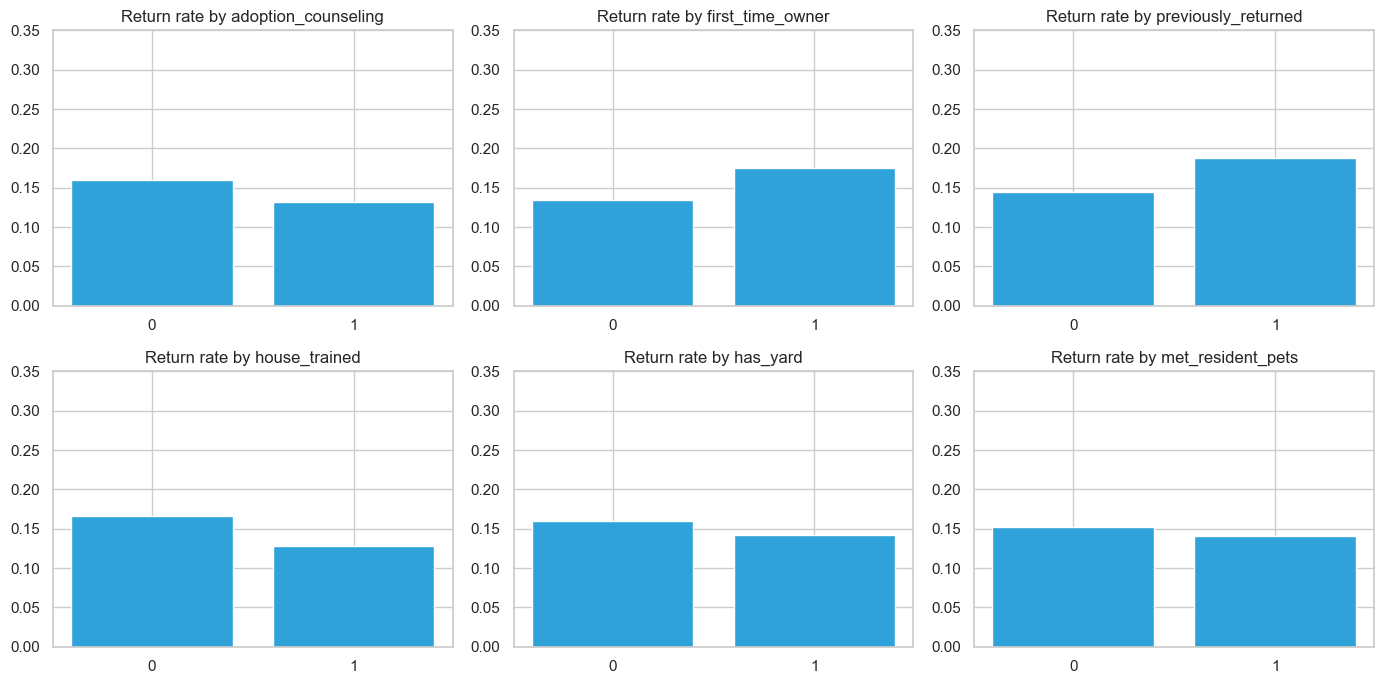

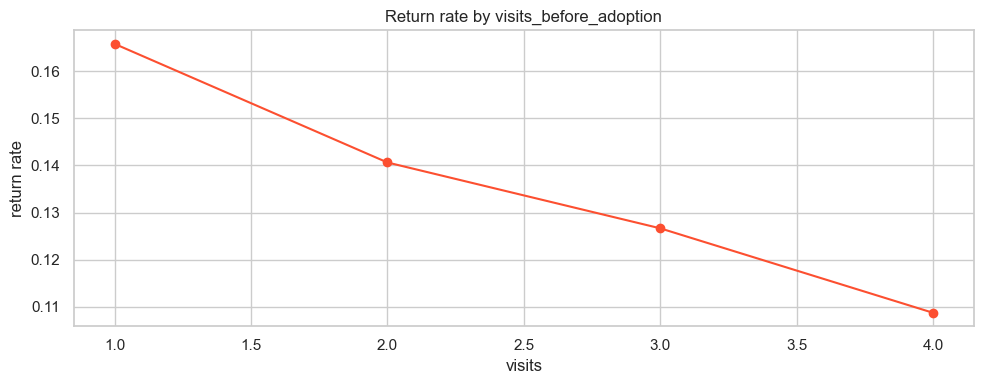

AGENT_SUMMARY process_return_rates:
adoption_counseling {0: 0.159, 1: 0.132}
first_time_owner {0: 0.134, 1: 0.176}
previously_returned {0: 0.145, 1: 0.188}
house_trained {0: 0.167, 1: 0.128}
has_yard {0: 0.16, 1: 0.143}
met_resident_pets {0: 0.152, 1: 0.141}
AGENT_SUMMARY visits_return:
                          mean  count
visits_before_adoption              
1                       0.166  21898
2                       0.141  11804
3                       0.127   5834
4                       0.109   2464


In [10]:
process_flags = ["adoption_counseling", "first_time_owner", "previously_returned", "house_trained", "has_yard", "met_resident_pets"]

f, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), process_flags):
    rates = df.groupby(col)["returned"].mean()
    ax.bar(rates.index.astype(str), rates.values, color="#30a2da")
    ax.set_title(f"Return rate by {col}")
    ax.set_ylim(0, max(0.35, rates.max() * 1.25))
plt.tight_layout()
plt.show()

visits = df.groupby("visits_before_adoption")["returned"].agg(["mean", "count"])
f, ax = plt.subplots(figsize=(10, 4))
ax.plot(visits.index, visits["mean"], marker="o", color="#fc4f30")
ax.set_title("Return rate by visits_before_adoption")
ax.set_xlabel("visits")
ax.set_ylabel("return rate")
plt.tight_layout()
plt.show()

print("AGENT_SUMMARY process_return_rates:")
for col in process_flags:
    print(col, df.groupby(col)["returned"].mean().round(3).to_dict())
print("AGENT_SUMMARY visits_return:\n", visits.round(3).to_string())


**Code Explanation:** <br>
Each binary process/context flag gets its own return-rate bar. Visits stay continuous (or integer-valued) as a line so I can see diminishing returns: whether the second visit matters more than the fifth.


# **7. Dog Size Deep Dive:** <a id="Size"></a>
### 7.1 Return rate by size
Size is more than a demographic label here — it changes housing fit, energy expectations, and which failure modes dominate when an adoption breaks. I start with the marginal return rate by size (with counts), then move to *why* returns happen within each size class.

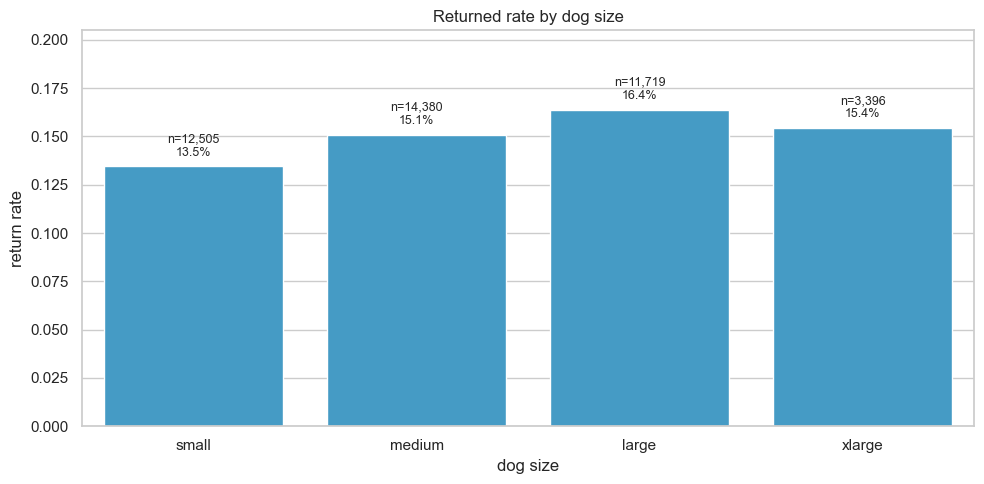

,n,n_returned,return_rate,return_rate_pct
size,,,,
small,12505,1683,0.134586,13.46
medium,14380,2169,0.150834,15.08
large,11719,1921,0.163922,16.39
xlarge,3396,524,0.154299,15.43


AGENT_SUMMARY return_rate_by_size:
             n  n_returned  return_rate  return_rate_pct
size                                                   
small   12505        1683        0.135            13.46
medium  14380        2169        0.151            15.08
large   11719        1921        0.164            16.39
xlarge   3396         524        0.154            15.43


In [11]:
# Return rate by dog size (with counts)
SIZE_ORDER = ["small", "medium", "large", "xlarge"]
assert set(df["size"].unique()) <= set(SIZE_ORDER)

size_ret = (
    df.groupby("size", observed=True)["returned"]
    .agg(n="count", n_returned="sum", return_rate="mean")
    .reindex(SIZE_ORDER)
)
size_ret["return_rate_pct"] = (100 * size_ret["return_rate"]).round(2)

f, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    x=size_ret.index.astype(str),
    y=size_ret["return_rate"].values,
    order=SIZE_ORDER,
    color="#30a2da",
    ax=ax,
)
for i, (idx, row) in enumerate(size_ret.iterrows()):
    ax.text(
        i,
        row["return_rate"] + 0.004,
        f"n={int(row['n']):,}\n{row['return_rate_pct']:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.set_ylim(0, max(size_ret["return_rate"].max() * 1.25, 0.05))
ax.set_ylabel("return rate")
ax.set_xlabel("dog size")
ax.set_title("Returned rate by dog size")
plt.tight_layout()
plt.show()

display(size_ret)
print("AGENT_SUMMARY return_rate_by_size:\n", size_ret.round(3).to_string())


**How to Interpret:** <br>
Each bar is \(P(\texttt{returned}=1 \mid \texttt{size})\). Annotations carry both **n** and the percentage so a tall bar on a tiny class cannot sneak past.

**Interpretation:** <br>
If return risk rises (or falls) smoothly from small→xlarge, size is a useful risk stratifier on its own — even before we interact it with home type. Flat bars would push the story toward *fit* and behavior rather than size per se.

### 7.2 Return reason by dog size

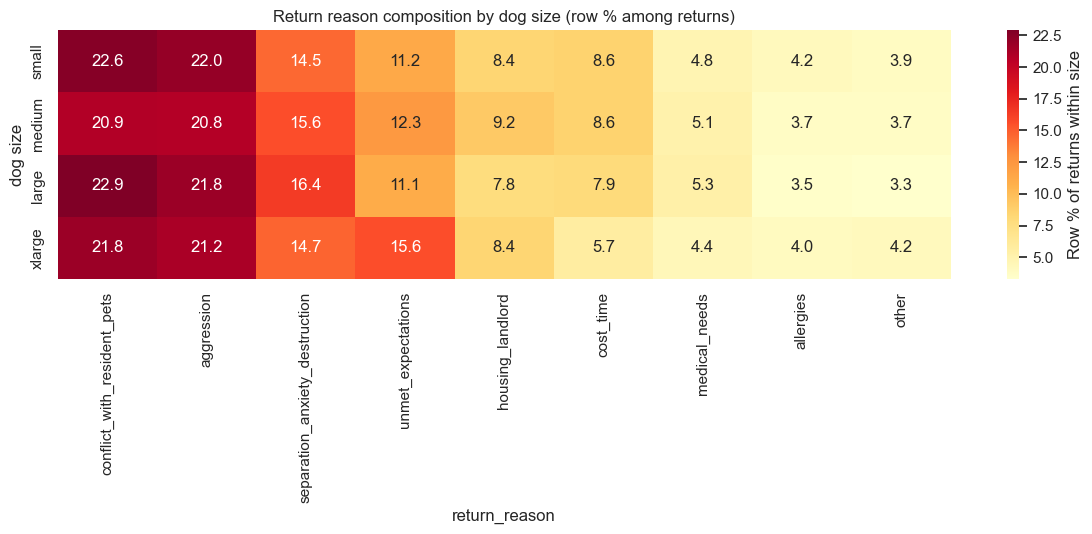

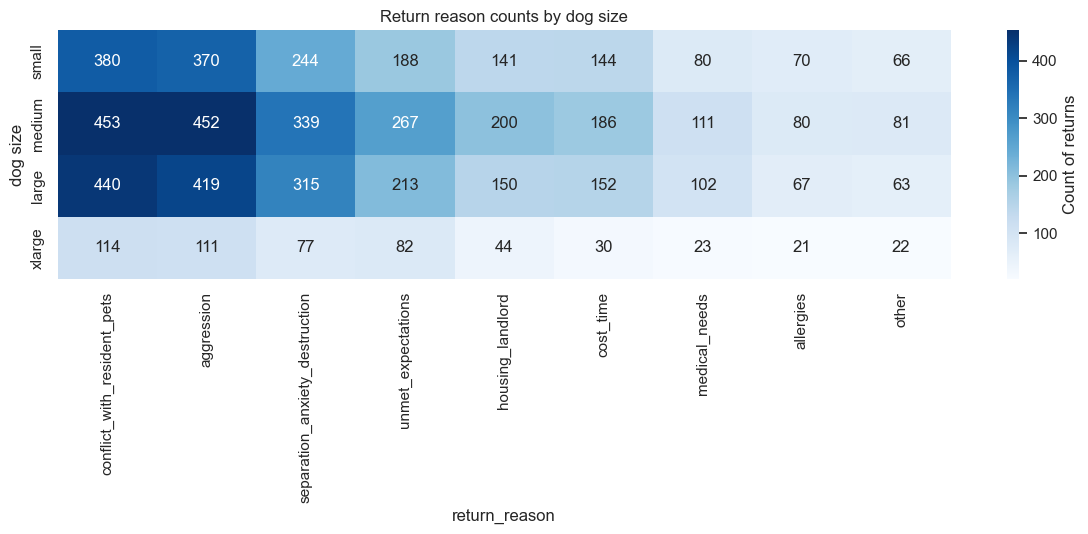

return_reason,conflict_with_resident_pets,aggression,separation_anxiety_destruction,unmet_expectations,housing_landlord,cost_time,medical_needs,allergies,other
size,,,,,,,,,
small,22.6,22.0,14.5,11.2,8.4,8.6,4.8,4.2,3.9
medium,20.9,20.8,15.6,12.3,9.2,8.6,5.1,3.7,3.7
large,22.9,21.8,16.4,11.1,7.8,7.9,5.3,3.5,3.3
xlarge,21.8,21.2,14.7,15.6,8.4,5.7,4.4,4.0,4.2


return_reason,conflict_with_resident_pets,aggression,separation_anxiety_destruction,unmet_expectations,housing_landlord,cost_time,medical_needs,allergies,other
size,,,,,,,,,
small,380,370,244,188,141,144,80,70,66
medium,453,452,339,267,200,186,111,80,81
large,440,419,315,213,150,152,102,67,63
xlarge,114,111,77,82,44,30,23,21,22


AGENT_SUMMARY return_reason_row_pct_by_size:
 return_reason  conflict_with_resident_pets  aggression  separation_anxiety_destruction  unmet_expectations  housing_landlord  cost_time  medical_needs  allergies  other
size                                                                                                                                                                    
small                                 22.6        22.0                            14.5                11.2               8.4        8.6            4.8        4.2    3.9
medium                                20.9        20.8                            15.6                12.3               9.2        8.6            5.1        3.7    3.7
large                                 22.9        21.8                            16.4                11.1               7.8        7.9            5.3        3.5    3.3
xlarge                                21.8        21.2                            14.7                15.6   

In [12]:
# Return reason mix by dog size (returns only — exclude "kept")
ret = df.loc[df["returned"] == 1].copy()
assert (ret["return_reason"] != "kept").all()

# Counts and row-% within size
reason_ct = pd.crosstab(ret["size"], ret["return_reason"]).reindex(index=SIZE_ORDER)
reason_pct = (
    pd.crosstab(ret["size"], ret["return_reason"], normalize="index")
    .mul(100)
    .round(1)
    .reindex(index=SIZE_ORDER)
)
# Order reason columns by overall frequency among returns
reason_order = ret["return_reason"].value_counts().index.tolist()
reason_ct = reason_ct.reindex(columns=reason_order)
reason_pct = reason_pct.reindex(columns=reason_order)

f, ax = plt.subplots(figsize=(12, 5.5))
sns.heatmap(
    reason_pct,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": "Row % of returns within size"},
)
ax.set_title("Return reason composition by dog size (row % among returns)")
ax.set_xlabel("return_reason")
ax.set_ylabel("dog size")
plt.tight_layout()
plt.show()

# Absolute counts companion — same layout, different units
f, ax = plt.subplots(figsize=(12, 5.5))
sns.heatmap(
    reason_ct.fillna(0).astype(int),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    cbar_kws={"label": "Count of returns"},
)
ax.set_title("Return reason counts by dog size")
ax.set_xlabel("return_reason")
ax.set_ylabel("dog size")
plt.tight_layout()
plt.show()

display(reason_pct)
display(reason_ct)
print("AGENT_SUMMARY return_reason_row_pct_by_size:\n", reason_pct.to_string())
print("AGENT_SUMMARY return_reason_counts_by_size:\n", reason_ct.to_string())

# Top reason per size (quick readout)
top_reason = reason_pct.idxmax(axis=1)
print("AGENT_SUMMARY top_reason_by_size:")
for s in SIZE_ORDER:
    print(f"  {s}: {top_reason.loc[s]} ({reason_pct.loc[s, top_reason.loc[s]]:.1f}% of that size's returns)")


**How to Interpret:** <br>
Row percentages answer: *given a return of a large dog, what share is aggression vs resident-pet conflict vs housing?* The count heatmap keeps sample size honest — a loud percentage on xlarge may rest on fewer returns.

**Interpretation:** <br>
Reason *mix* can shift even when overall return rates are similar. Small dogs might fail more on separation anxiety / landlord housing; large/xlarge more on aggression or space. That distinction matters operationally: the same “return rate” can hide different interventions.


# **8. Crosstabs: Size × Home, Kids × Aggression:** <a id="Crosstabs"></a>


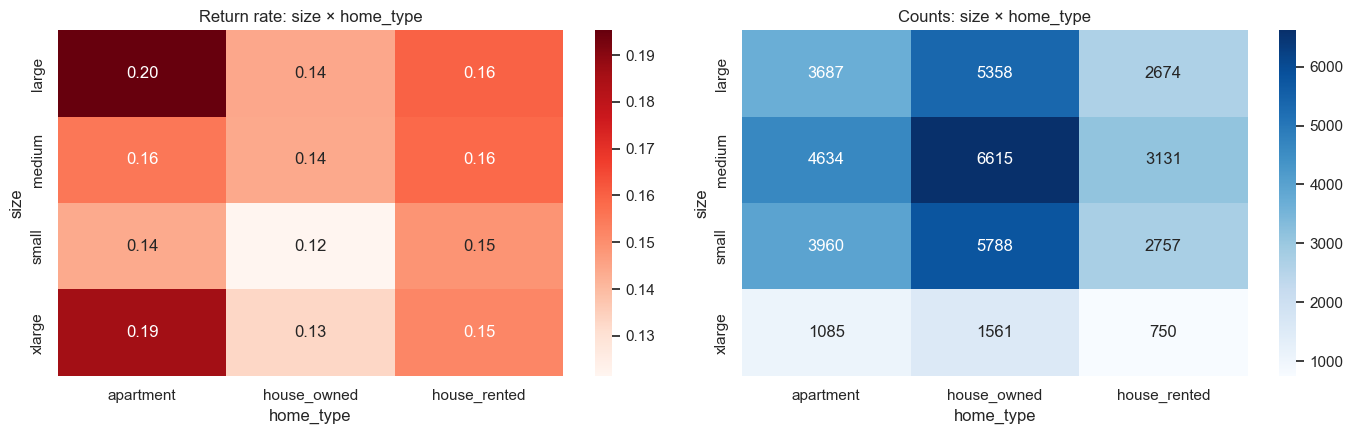

AGENT_SUMMARY size_home_return_rate:
 home_type  apartment  house_owned  house_rented
size                                           
large          0.195        0.144         0.160
medium         0.155        0.144         0.158
small          0.144        0.121         0.149
xlarge         0.186        0.133         0.152


In [13]:
# size × home_type return rates
ct = pd.crosstab(df["size"], df["home_type"], values=df["returned"], aggfunc="mean")
ct_n = pd.crosstab(df["size"], df["home_type"])

f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Reds", ax=ax[0])
ax[0].set_title("Return rate: size × home_type")
sns.heatmap(ct_n, annot=True, fmt="d", cmap="Blues", ax=ax[1])
ax[1].set_title("Counts: size × home_type")
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY size_home_return_rate:\n", ct.round(3).to_string())


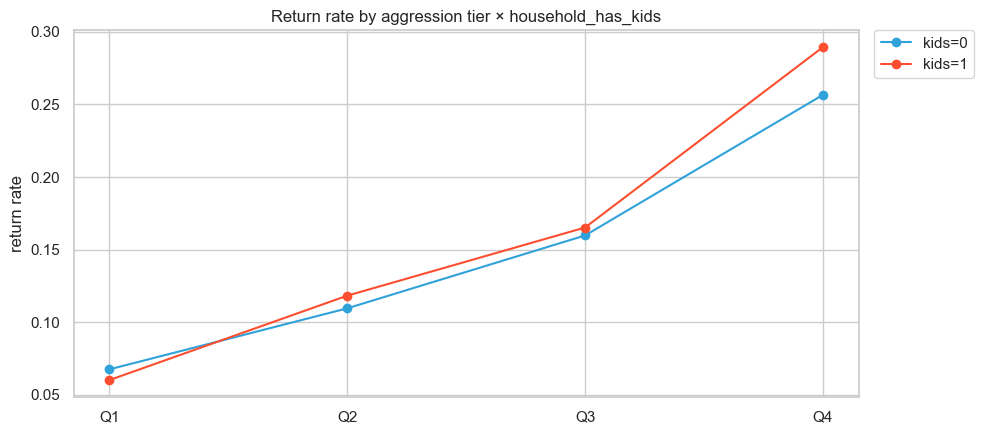

AGENT_SUMMARY kids_aggression_return:
  household_has_kids aggression_tier  mean  count
                  0              Q1 0.068   7129
                  0              Q2 0.110   7024
                  0              Q3 0.160   6839
                  0              Q4 0.257   6730
                  1              Q1 0.060   3670
                  1              Q2 0.118   3625
                  1              Q3 0.165   3594
                  1              Q4 0.289   3389


In [14]:
# kids × aggression
tmp = df.copy()
tmp["aggression_tier"] = pd.qcut(tmp["aggression_score"], 4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop")
kid_agg = tmp.groupby(["household_has_kids", "aggression_tier"], observed=True)["returned"].agg(["mean", "count"]).reset_index()

f, ax = plt.subplots(figsize=(10, 4.5))
for kids, color in [(0, "#30a2da"), (1, "#fc4f30")]:
    sub = kid_agg[kid_agg["household_has_kids"] == kids]
    ax.plot(sub["aggression_tier"].astype(str), sub["mean"], marker="o", color=color, label=f"kids={kids}")
ax.set_title("Return rate by aggression tier × household_has_kids")
ax.set_ylabel("return rate")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY kids_aggression_return:\n", kid_agg.round(3).to_string(index=False))


**How to Interpret:** <br>
The size × home heatmap answers: *among large dogs in apartments, what fraction return?* Count heatmaps beside rate heatmaps prevent me from overreading a bright cell with n=12. The kids × aggression lines ask whether high aggression is especially costly in households with children — an interaction hypothesis, still associational.


# **9. Multivariate Association:** <a id="Association"></a>


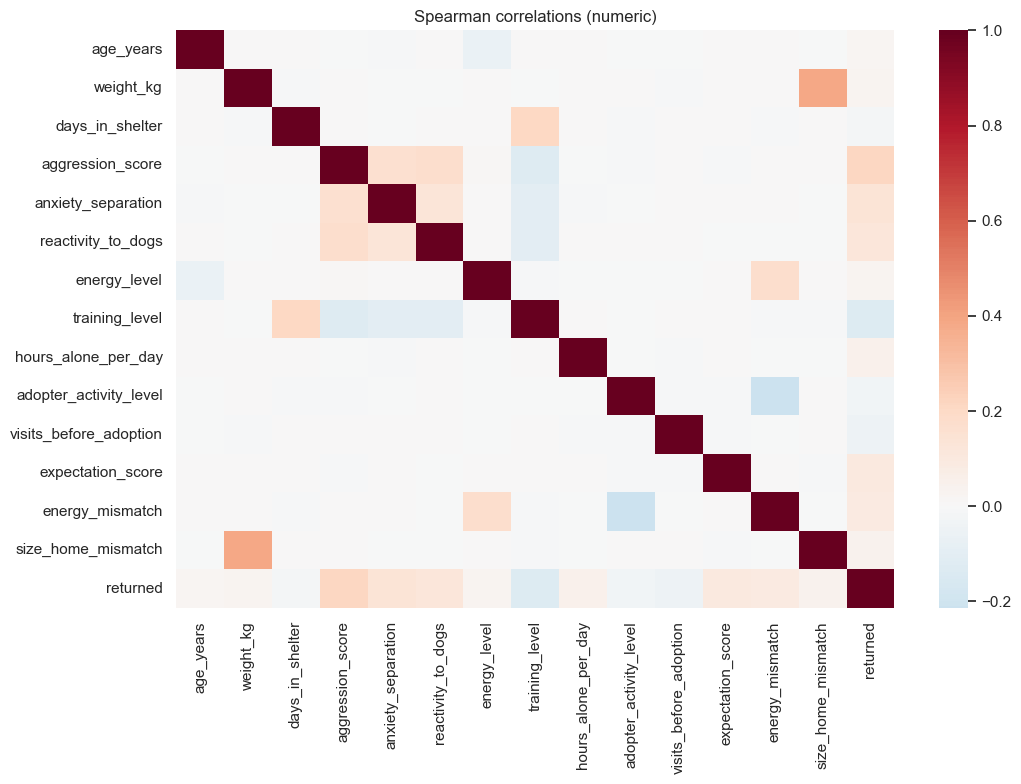

AGENT_SUMMARY corr_with_returned:
 aggression_score          0.214
anxiety_separation        0.141
training_level           -0.136
reactivity_to_dogs        0.124
expectation_score         0.102
energy_mismatch           0.087
visits_before_adoption   -0.050
hours_alone_per_day       0.048
size_home_mismatch        0.043
adopter_activity_level   -0.030
weight_kg                 0.028
energy_level              0.025
age_years                 0.021
days_in_shelter          -0.016


In [15]:
num_corr_cols = [
    "age_years", "weight_kg", "days_in_shelter", "aggression_score", "anxiety_separation",
    "reactivity_to_dogs", "energy_level", "training_level", "hours_alone_per_day",
    "adopter_activity_level", "visits_before_adoption", "expectation_score",
    "energy_mismatch", "size_home_mismatch", "returned",
]
corr = df[num_corr_cols].corr(method="spearman")

f, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Spearman correlations (numeric)")
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY corr_with_returned:\n",
      corr["returned"].drop("returned").sort_values(key=np.abs, ascending=False).round(3).to_string())


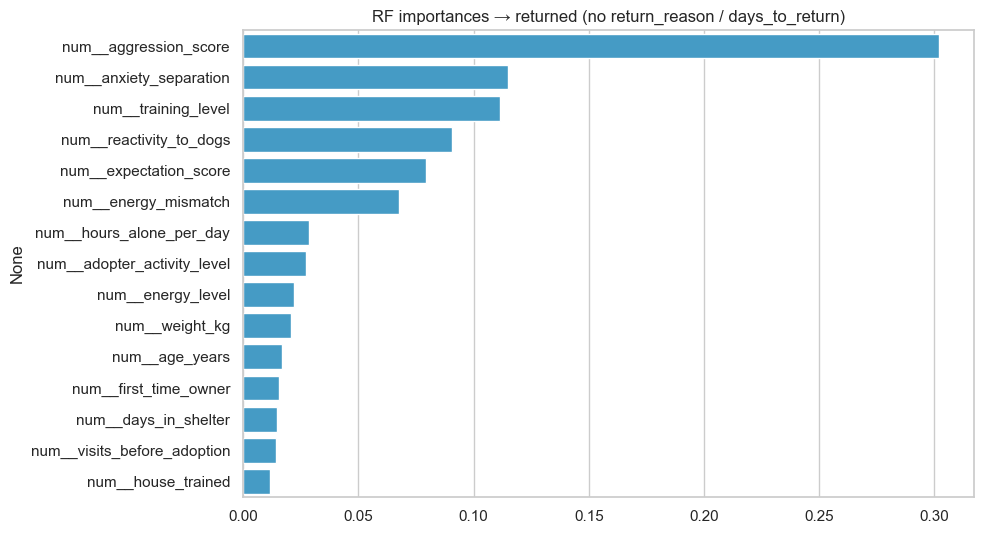

AGENT_SUMMARY rf_top15:
 num__aggression_score          0.302
num__anxiety_separation        0.115
num__training_level            0.111
num__reactivity_to_dogs        0.091
num__expectation_score         0.079
num__energy_mismatch           0.068
num__hours_alone_per_day       0.029
num__adopter_activity_level    0.027
num__energy_level              0.022
num__weight_kg                 0.021
num__age_years                 0.017
num__first_time_owner          0.015
num__days_in_shelter           0.014
num__visits_before_adoption    0.014
num__house_trained             0.012
AGENT_SUMMARY train_acc=0.850 base_rate=0.150


In [16]:
# RF importances for returned — exclude return_reason and days_to_return (leakage / post-outcome)
feat_cat = ["size", "breed_group", "intake_type", "medical_needs", "home_type"]
feat_num = [
    "age_years", "weight_kg", "days_in_shelter", "previously_returned", "neutered",
    "aggression_score", "anxiety_separation", "reactivity_to_dogs", "energy_level",
    "training_level", "house_trained", "first_time_owner", "household_has_kids",
    "household_has_pets", "has_yard", "hours_alone_per_day", "adopter_activity_level",
    "visits_before_adoption", "met_resident_pets", "adoption_counseling",
    "expectation_score", "energy_mismatch", "size_home_mismatch",
]
assert "return_reason" not in feat_cat + feat_num
assert "days_to_return" not in feat_cat + feat_num

X = df[feat_cat + feat_num]
y = df["returned"]
assert X.isna().sum().sum() == 0, "unexpected NA in model features"

pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), feat_cat),
    ("num", "passthrough", feat_num),
])
pipe = Pipeline([
    ("pre", pre),
    ("rf", RandomForestClassifier(
        n_estimators=250, max_depth=8, min_samples_leaf=40,
        random_state=0, n_jobs=-1,
    )),
])
pipe.fit(X, y)
imp = pd.Series(
    pipe.named_steps["rf"].feature_importances_,
    index=pipe.named_steps["pre"].get_feature_names_out(),
).sort_values(ascending=False).head(15)

f, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(x=imp.values, y=imp.index, ax=ax, color="#30a2da")
ax.set_title("RF importances → returned (no return_reason / days_to_return)")
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY rf_top15:\n", imp.round(3).to_string())
print("AGENT_SUMMARY train_acc={:.3f} base_rate={:.3f}".format(pipe.score(X, y), y.mean()))


**How to Interpret:** <br>
`return_reason` and `days_to_return` are excluded on purpose — the first partly encodes the outcome, the second is only defined after a return. Importances are full-table exploratory fit. Behavior scores and mismatch features often rise; process flags may look weaker once behavior is in the model. This is a map of associations, not a shelter scoring system.


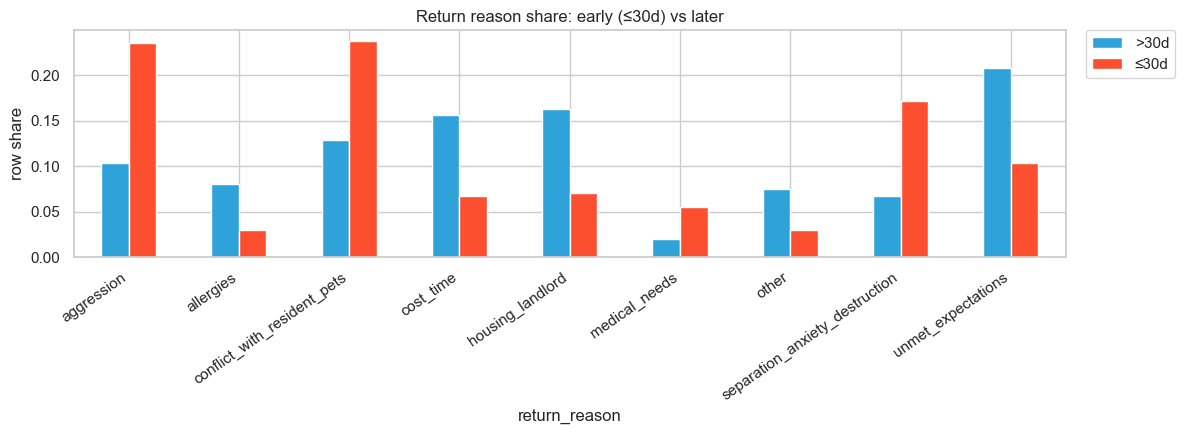

AGENT_SUMMARY early_return_share=84.5%
AGENT_SUMMARY reason_by_timing:
 return_reason  aggression  allergies  conflict_with_resident_pets  cost_time  housing_landlord  medical_needs  other  separation_anxiety_destruction  unmet_expectations
early                                                                                                                                                                   
>30d                0.104       0.08                        0.128      0.156             0.163          0.021  0.075                           0.067               0.207
≤30d                0.235       0.03                        0.237      0.068             0.071          0.056  0.030                           0.171               0.103


In [17]:
# Early vs later returns — reason mix
ret = df[df["returned"] == 1].copy()
ret["early"] = (ret["days_to_return"] <= 30).astype(int)
reason_early = pd.crosstab(ret["early"].map({1: "≤30d", 0: ">30d"}), ret["return_reason"], normalize="index")

f, ax = plt.subplots(figsize=(12, 4.5))
reason_early.T.plot(kind="bar", ax=ax, color=["#30a2da", "#fc4f30"])
ax.set_title("Return reason share: early (≤30d) vs later")
ax.set_ylabel("row share")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY early_return_share={:.1%}".format(ret["early"].mean()))
print("AGENT_SUMMARY reason_by_timing:\n", reason_early.round(3).to_string())


**Interpretation:** <br>
If aggression and resident-pet conflict dominate early returns while cost/housing rise later, the clock is telling a story about *when* different failure modes appear. That timing split is actionable for follow-up calls even when overall return rate is the headline KPI.


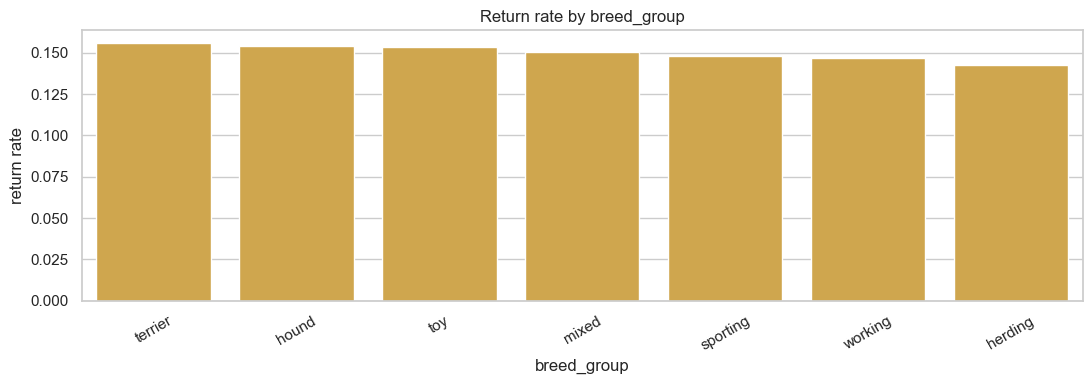

AGENT_SUMMARY breed_group_return:
               mean  count
breed_group              
terrier      0.156   4693
hound        0.154   4168
toy          0.154   3687
mixed        0.150  14748
sporting     0.148   5427
working      0.147   4175
herding      0.143   5102


In [18]:
# Breed group return rates
bg = df.groupby("breed_group")["returned"].agg(["mean", "count"]).sort_values("mean", ascending=False)
f, ax = plt.subplots(figsize=(11, 4))
sns.barplot(x=bg.index, y=bg["mean"], ax=ax, color="#e5ae38")
ax.set_title("Return rate by breed_group")
ax.tick_params(axis="x", rotation=30)
ax.set_ylabel("return rate")
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY breed_group_return:\n", bg.round(3).to_string())


**Code Explanation:** <br>
Breed group is a coarse typology, not a destiny. I plot return rates with counts in the printed table so a high-rate group with tiny n does not hijack the narrative.


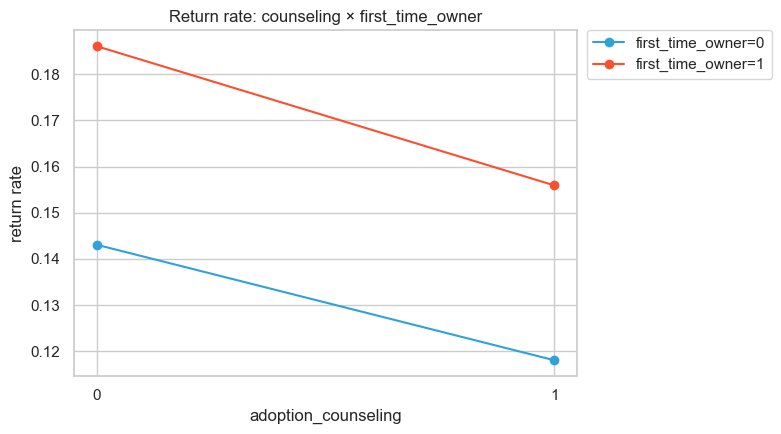

AGENT_SUMMARY counseling_first_time:
  adoption_counseling  first_time_owner  mean  count
                   0                 0 0.143  16996
                   0                 1 0.186  10311
                   1                 0 0.118   9114
                   1                 1 0.156   5579


In [19]:
# Counseling × first_time_owner interaction
ct = df.groupby(["adoption_counseling", "first_time_owner"])["returned"].agg(["mean", "count"]).reset_index()
f, ax = plt.subplots(figsize=(8, 4.5))
for ft, color in [(0, "#30a2da"), (1, "#fc4f30")]:
    sub = ct[ct["first_time_owner"] == ft]
    ax.plot(sub["adoption_counseling"], sub["mean"], marker="o", color=color, label=f"first_time_owner={ft}")
ax.set_xticks([0, 1])
ax.set_title("Return rate: counseling × first_time_owner")
ax.set_xlabel("adoption_counseling")
ax.set_ylabel("return rate")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY counseling_first_time:\n", ct.round(3).to_string(index=False))


**How to Interpret:** <br>
Parallel lines suggest counseling associates similarly for new and experienced owners; a wedge suggests an interaction. Either way, selection into counseling (who receives it) can mimic a treatment effect — keep that caveat next to any hopeful reading.


# **10. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A large adoption panel with dog behavior, household fit, process features, engineered mismatches, and a ~15% return outcome. Days-to-return exist only for returns; `"kept"` is the non-event reason.

**What stands out:** <br>
1. **Most adoptions stick**, but returns are common enough (~15%) to study systematically.
2. **Returns arrive early** — the days-to-return distribution is front-loaded.
3. **Fit mismatches track returns** — energy mismatch quintiles and size–home flags move rates in the expected direction.
4. **Behavior scores matter** — aggression and separation anxiety densities separate kept vs returned.
5. **Process levers are mixed** — counseling and visits deserve attention, but they compete with trait/fit features in multivariate views.
6. **Kids × aggression is an interaction worth watching** — high aggression in homes with children is a high-stakes cell.
7. **Dog size shapes both return risk and *why* returns happen** — rate gradients by size, and reason mix shifts across small→xlarge.

**Open follow-ups:** <br>
- Which return reasons dominate the first 30 days versus later returns?
- Does counseling help most for first-time owners, or is the association uniform?
- Can size × home effects be explained entirely by `size_home_mismatch`, or is there residual structure?
- Would a model without engineered mismatches recover the same rankings from raw fields alone?
